<a href="https://colab.research.google.com/github/yannn-6243/PCD_Assignment02/blob/main/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Nama : Hadyan Althaf Baswara<br>
##NIM : 25/559377/PA/23527
##PCD Assignment 02

#Library

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

over = cv2.imread('/content/bright image.jpg')
dark = cv2.imread('/content/dark image.jpg')
blur = cv2.imread('/content/blur image.jpg')
low = cv2.imread('/content/low contrast.jpg')
noise = cv2.imread('/content/salt pepper.jpg')
noise2 = cv2.imread('/content/general noise.jpg')
hist_eq = cv2.imread('/content/histogram equal.jpg')
high = cv2.imread('/content/high pass.jpg')


over = cv2.cvtColor(over, cv2.COLOR_BGR2RGB)
dark = cv2.cvtColor(dark, cv2.COLOR_BGR2RGB)
blur = cv2.cvtColor(blur, cv2.COLOR_BGR2RGB)
low = cv2.cvtColor(low, cv2.COLOR_BGR2RGB)
noise = cv2.cvtColor(noise, cv2.COLOR_BGR2RGB)
noise2 = cv2.cvtColor(noise2, cv2.COLOR_BGR2RGB)
hist_eq = cv2.cvtColor(hist_eq, cv2.COLOR_BGR2RGB)
high = cv2.cvtColor(high, cv2.COLOR_BGR2RGB)

## 1. Citra Terlalu Terang (Overexposed)
### Metode: Gamma Correction

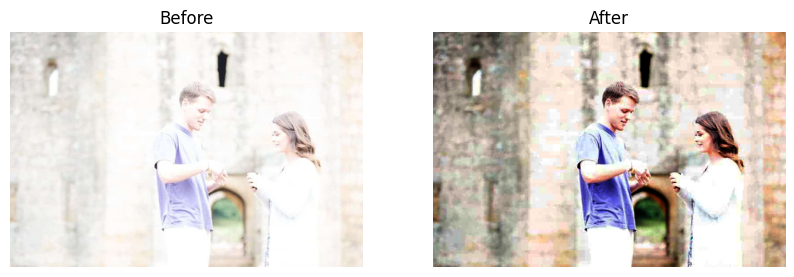

In [7]:
gamma = 5.0

over_norm = over / 255.0
over_enhance = np.power(over_norm, gamma)
over_enhance = np.uint8(over_enhance * 255)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(over)
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(over_enhance)
plt.title('After')
plt.axis('off')

plt.show()

## 2. Citra Terlalu Gelap (Underexposed)
### Metode: Gamma Correction

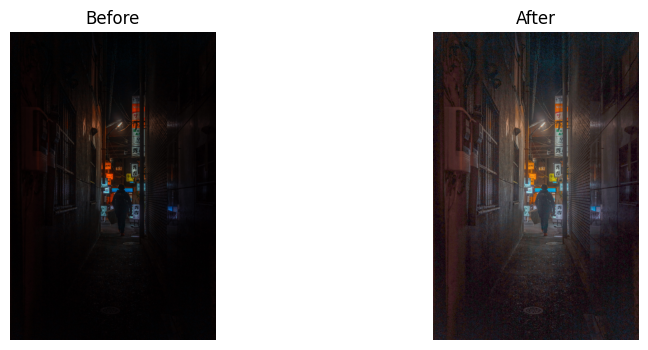

In [8]:
gamma = 0.5

dark_norm = dark / 255.0
dark_enhance = np.power(dark_norm, gamma)
dark_enhance = np.uint8(dark_enhance * 255)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(dark)
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dark_enhance)
plt.title('After')
plt.axis('off')

plt.show()

## 3. Citra Buram (Blurred)
### Metode: Laplacian Sharpening


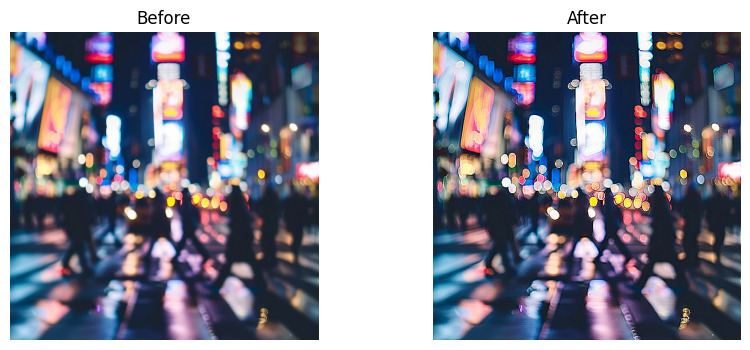

In [9]:
laplacian = cv2.Laplacian(blur, cv2.CV_64F)

hasil_blur = blur.astype(np.float64) - 1.5 * laplacian
hasil_blur = np.clip(hasil_blur, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(blur)
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_blur)
plt.title('After')
plt.axis('off')

plt.show()

## 4. Citra dengan Kontras Rendah (Low Contrast)
### Metode: CLAHE


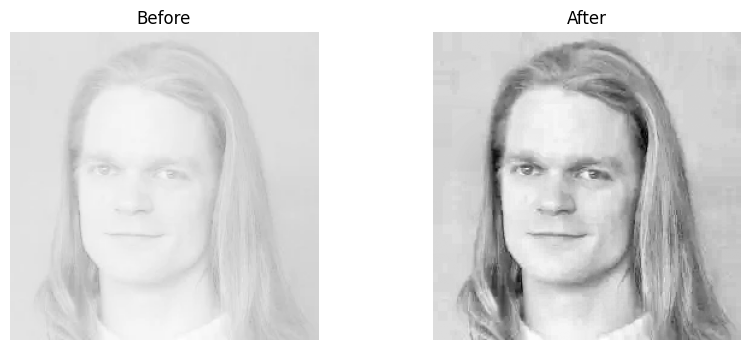

In [15]:
gray = cv2.cvtColor(low, cv2.COLOR_RGB2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
low_enhance = clahe.apply(gray)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(low, cmap='gray')
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(low_enhance, cmap='gray')
plt.title('After')
plt.axis('off')

plt.show()

## 5. Citra dengan Salt-and-Pepper Noise
### Metode: Median Filter

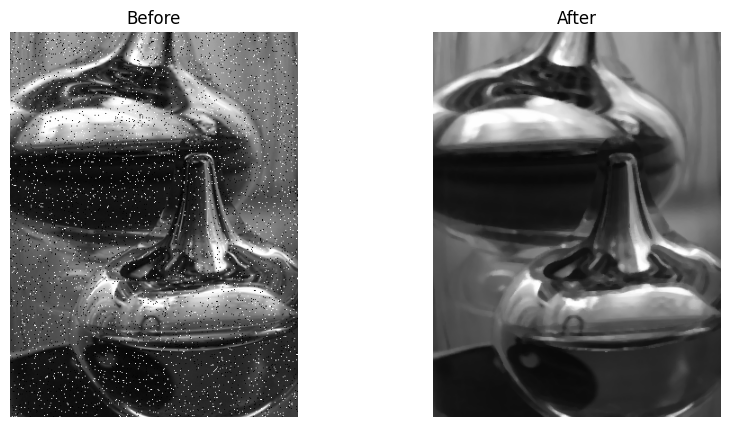

In [11]:
noise = cv2.imread('/content/salt pepper.jpg')
noise = cv2.cvtColor(noise, cv2.COLOR_BGR2RGB)

hasil_5 = cv2.medianBlur(noise, 5)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(noise)
plt.title('Before')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hasil_5)
plt.title('After')
plt.axis('off')
plt.show()

## 6. Citra dengan General/Grain Noise
### Metode: Mean/Average Filter

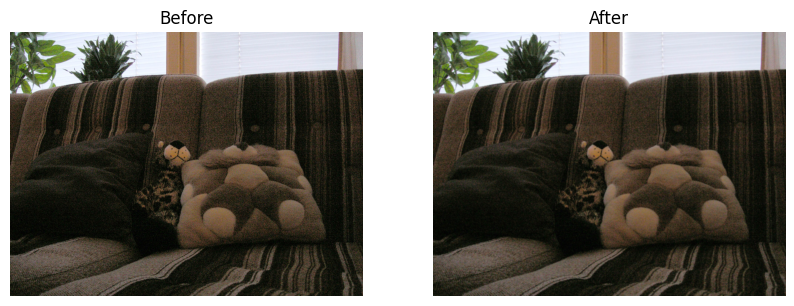

In [17]:
noise2 = cv2.imread('/content/general noise.jpg')
noise2 = cv2.cvtColor(noise2, cv2.COLOR_BGR2RGB)
hasil_6 = cv2.blur(noise2, (5,5))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(noise2)
plt.title('Before')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hasil_6)
plt.title('After')
plt.axis('off')
plt.show()

## 7. Distribusi Intensitas Piksel Kurang Tersebar
### Metode: Histogram Equalization

/tmp/ipykernel_826/1677078317.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0, 256])
/tmp/ipykernel_826/1677078317.py:22: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(hasil_7.ravel(), 256, [0, 256])


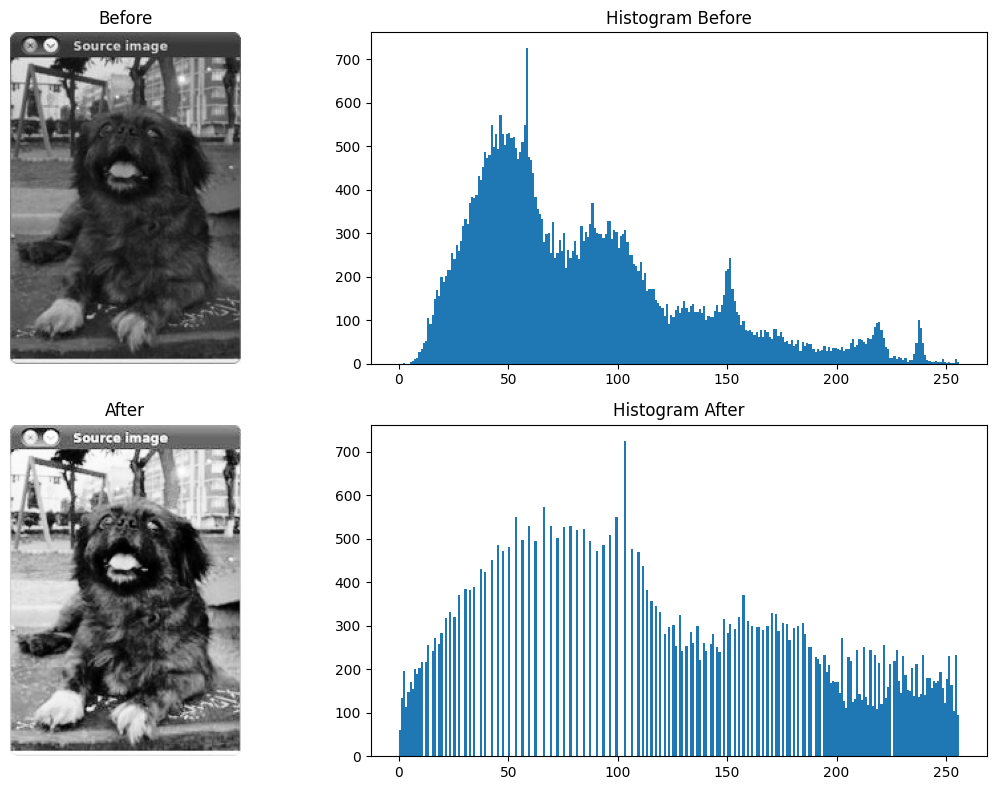

In [13]:
gray = cv2.cvtColor(hist_eq, cv2.COLOR_RGB2GRAY)

hasil_7 = cv2.equalizeHist(gray)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Before')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.hist(gray.ravel(), 256, [0, 256])
plt.title('Histogram Before')

plt.subplot(2, 2, 3)
plt.imshow(hasil_7, cmap='gray')
plt.title('After')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.hist(hasil_7.ravel(), 256, [0, 256])
plt.title('Histogram After')

plt.tight_layout()
plt.show()

##8. Citra dengan Detail dan Tepi yang Kurang Menonjol
###Metode: High-Pass Filter (Frequency Domain)

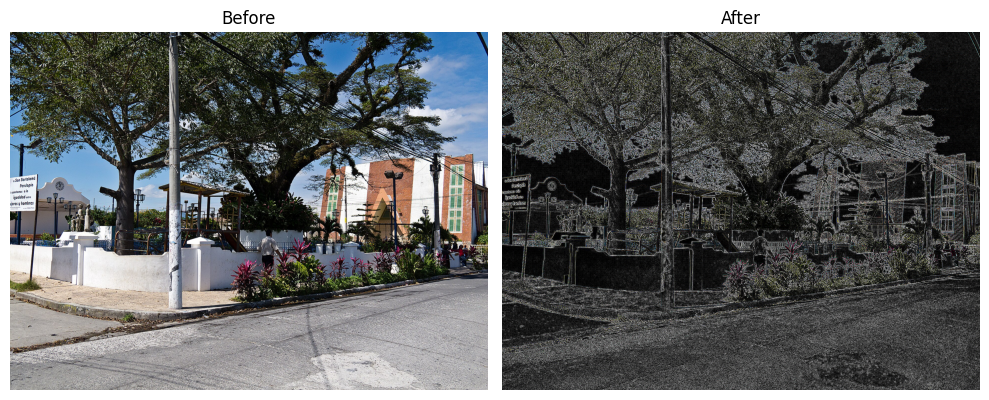

In [14]:
high = cv2.imread('/content/high pass.jpg')
high = cv2.cvtColor(high, cv2.COLOR_BGR2RGB)

kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

hasil_9 = cv2.filter2D(high, -1, kernel)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(high)
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_9)
plt.title('After')
plt.axis('off')

plt.tight_layout()
plt.show()